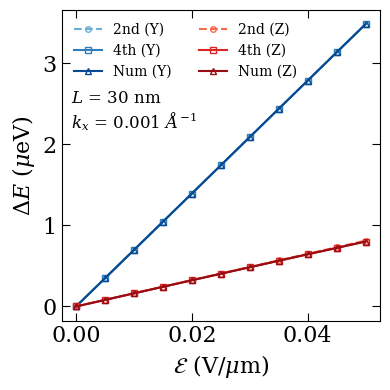

----------------------------------------
E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)
----------------------------------------
0.005 0.348 6967.834
0.01 0.697 6967.819
0.015 1.045 6967.794
0.02 1.394 6967.76
0.025 1.742 6967.715
0.03 2.09 6967.661
0.035 2.439 6967.597
0.04 2.787 6967.523
0.045 3.135 6967.44
0.05 3.484 6967.346
----------------------------------------
E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)
----------------------------------------
0.005 0.081 1619.317
0.01 0.162 1618.786
0.015 0.243 1617.903
0.02 0.323 1616.672
0.025 0.404 1615.098
0.03 0.484 1613.189
0.035 0.564 1610.951
0.04 0.643 1608.395
0.045 0.722 1605.53
0.05 0.801 1602.367


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
#                      GLOBAL SETTINGS
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [4, 4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==============================================================
#                      SPLITTING PLOT
# ==============================================================
N = 100
L = 300
kx = 0.001
emax = 0.05

datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_y.dat", skiprows=1)

Efield = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]
split_pb_2nd_y = datay_pb[:, 2]
split_pb_4th_y = datay_pb[:, 3]
split_num_y = datay_num[:, 3]



dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_z.dat", skiprows=1)

Efield = dataz_pb[:, 0]
alpha_z = dataz_pb[:, 1]
split_pb_2nd_z = dataz_pb[:, 2]
split_pb_4th_z = dataz_pb[:, 3]
split_num_z = dataz_num[:, 3]

# Color maps
cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds

# Pick 3 shades (light → dark)
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ==============================================================
#                      PLOT
# ==============================================================

fig, ax = plt.subplots()

# Y = blue, Z = red

# Y direction (Blues)
ax.plot(Efield, split_pb_2nd_y, 'o--', color=blue_colors[0],
        label="2nd (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_pb_4th_y, 's-', color=blue_colors[1],
        label="4th (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_y, '^-', color=blue_colors[2],
        label="Num (Y)", markersize=4, markerfacecolor='None')


# Z direction (Reds)
ax.plot(Efield, split_pb_2nd_z, 'o--', color=red_colors[0],
        label="2nd (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_pb_4th_z, 's-', color=red_colors[1],
        label="4th (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_z, '^-', color=red_colors[2],
        label="Num (Z)", markersize=4, markerfacecolor='None')

ax.legend(frameon=False, ncol=2, fontsize = 10)
ax.text(0.03,0.62,f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax.transAxes, fontsize = 12)
ax.text(0.03,0.7,f"$L$ = {int(L/10)} nm", transform=ax.transAxes,fontsize = 12)


# Labels
ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize = 16)
ax.set_ylabel(r"$\Delta E$ ($\mu$eV)", fontsize = 16)
ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=16)

plt.tight_layout()
plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.png",dpi=300)
plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.pdf",dpi=300)
plt.show()

print("-"*40)
print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
print("-"*40)
for i in range(1,len(Efield)):
    print(Efield[i].round(3), split_num_y[i].round(3), (split_num_y[i]/(Efield[i]*kx*10)).round(3))

print("-"*40)
print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
print("-"*40)
for i in range(1,len(Efield)):
    print(Efield[i].round(3), split_num_z[i].round(3), (split_num_z[i]/(Efield[i]*kx*10)).round(3))

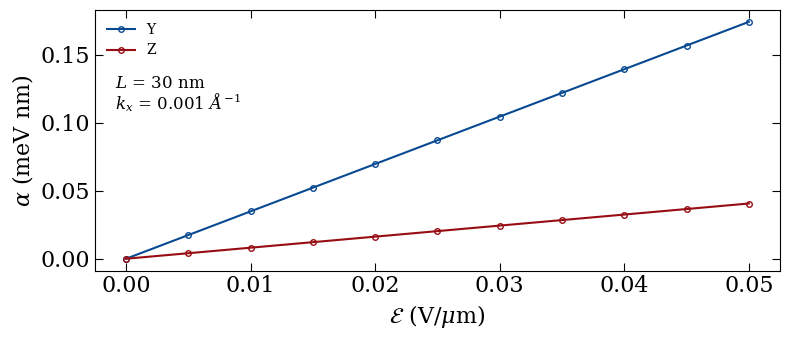

In [23]:

# ==============================================================
#                      RASHBA COEFFICIENT
# ==============================================================
N = 100
L = 300
kx = 0.001
emax = 0.05

datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_y.dat", skiprows=1)

Efield = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]

dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_z.dat", skiprows=1)

Efield = dataz_pb[:, 0]
alpha_z = dataz_pb[:, 1]


fig, ax = plt.subplots()

# Y = blue, Z = red

# Y direction (Blues)
ax.plot(Efield, alpha_y*1e2, 'o-', color=blue_colors[2],
        label="Y", markersize=4, markerfacecolor='None')

# Z direction (Reds)
ax.plot(Efield, alpha_z*1e2, 'o-', color=red_colors[2],
        label="Z", markersize=4, markerfacecolor='None')

ax.legend(frameon=False, ncol=1, fontsize = 10)
ax.text(0.03,0.62,f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax.transAxes, fontsize = 12)
ax.text(0.03,0.7,f"$L$ = {int(L/10)} nm", transform=ax.transAxes,fontsize = 12)
# ax.set_xlim(0,0.06)


# Labels
ax.set_ylabel(r"$\alpha$ (meV nm)", fontsize = 16)
ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize = 16)
ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=16)

plt.tight_layout()
plt.savefig(f"alpha_plot_N{N}_L{L}_kx{kx}.png",dpi=300)
plt.savefig(f"alpha_plot_N{N}_L{L}_kx{kx}.pdf",dpi=300)
plt.show()

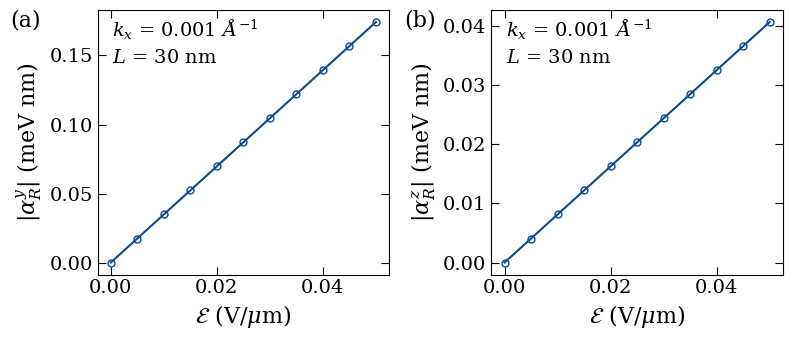

In [24]:
# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [8, 3.5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ======= CREATE 1x2 GRID =======
fig, (ax1, ax2) = plt.subplots(1, 2)

# --- Left Plot: Y Direction ---
ax1.plot(Efield, alpha_y * 1e2, 'o-', color=blue_colors[2],
         label=r"$\alpha_y$", markersize=5, markerfacecolor='None')
ax1.set_ylabel(r"$|\alpha_R^y|$ (meV nm)", fontsize=16)

# --- Right Plot: Z Direction ---
ax2.plot(Efield, alpha_z * 1e2, 'o-', color=blue_colors[2],
         label=r"$\alpha_z$", markersize=5, markerfacecolor='None')
ax2.set_ylabel(r"$|\alpha_R^z|$ (meV nm)", fontsize=16)

# --- Common Formatting ---
for ax in [ax1, ax2]:
    ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize=16)
    ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=14)

# --- Text annotations ---
ax1.text(0.05, 0.9, f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax1.transAxes, fontsize=14)
ax1.text(0.05, 0.8, f"$L$ = {int(L/10)} nm", transform=ax1.transAxes, fontsize=14)
# ax1.text(0.05, 0.9, r"$\mathcal{E}$ || $y$", transform=ax1.transAxes, fontsize=14)

ax2.text(0.05, 0.9, f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax2.transAxes, fontsize=14)
ax2.text(0.05, 0.8, f"$L$ = {int(L/10)} nm", transform=ax2.transAxes, fontsize=14)
# ax2.text(0.05, 0.9, r"$\mathcal{E}$ || $z$", transform=ax2.transAxes, fontsize=14)

# --- Panel labels (a), (b) ---
ax1.text(-0.3, 1., "(a)", transform=ax1.transAxes,
         fontsize=16, va='top')

ax2.text(-0.3, 1., "(b)", transform=ax2.transAxes,
         fontsize=16, va='top')

# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.35)  # <-- increase spacing here

# Save
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}.png", dpi=300)
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}.pdf", dpi=300)
plt.show()

===== Linear fit results =====
Y field: alpha_y = 3.4848e+00 E + 2.4533e-18, R^2 = 1.000000
Z field: alpha_z = 8.1255e-01 E + 0.0000e+00, R^2 = 1.000000


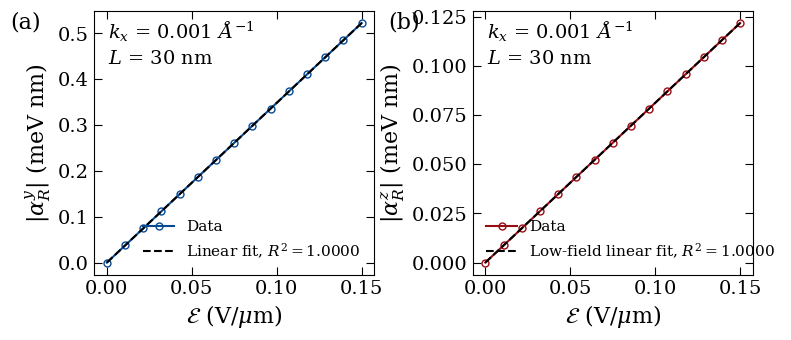

In [14]:
# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [8, 3.5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==================================================
# Linear fit settings
# ==================================================
linear_fit_Emax = 0.02   # V/um; choose low-field region for fitting

alpha_y_plot = alpha_y * 1e2   # meV nm
alpha_z_plot = alpha_z * 1e2   # meV nm

fit_mask = Efield <= linear_fit_Emax

def linear_fit_and_r2(x, y, mask):
    """
    Fit y = m x + c using selected mask.
    Return slope, intercept, fitted y over full x, and R^2 in fitted region.
    """
    m, c = np.polyfit(x[mask], y[mask], 1)
    yfit_full = m * x + c

    yfit_region = m * x[mask] + c
    ss_res = np.sum((y[mask] - yfit_region)**2)
    ss_tot = np.sum((y[mask] - np.mean(y[mask]))**2)
    r2 = 1 - ss_res / ss_tot

    return m, c, yfit_full, r2

my, cy, alpha_y_fit, r2_y = linear_fit_and_r2(Efield, alpha_y_plot, fit_mask)
mz, cz, alpha_z_fit, r2_z = linear_fit_and_r2(Efield, alpha_z_plot, fit_mask)

print("===== Linear fit results =====")
print(f"Y field: alpha_y = {my:.4e} E + {cy:.4e}, R^2 = {r2_y:.6f}")
print(f"Z field: alpha_z = {mz:.4e} E + {cz:.4e}, R^2 = {r2_z:.6f}")



cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])
# ======= CREATE 1x2 GRID =======
fig, (ax1, ax2) = plt.subplots(1, 2)

# --- Left Plot: Y Direction ---
ax1.plot(
    Efield, alpha_y_plot, 'o-',
    color=blue_colors[2],
    label=r"Data",
    markersize=5,
    markerfacecolor='None'
)

ax1.plot(
    Efield, alpha_y_fit, '--',
    color='black',
    linewidth=1.5,
    label=fr"Linear fit, $R^2={r2_y:.4f}$"
)

ax1.set_ylabel(r"$|\alpha_R^y|$ (meV nm)", fontsize=16)


# --- Right Plot: Z Direction ---
ax2.plot(
    Efield, alpha_z_plot, 'o-',
    color=red_colors[2],
    label=r"Data",
    markersize=5,
    markerfacecolor='None'
)

ax2.plot(
    Efield, alpha_z_fit, '--',
    color='black',
    linewidth=1.5,
    label=fr"Low-field linear fit, $R^2={r2_z:.4f}$"
)

ax2.set_ylabel(r"$|\alpha_R^z|$ (meV nm)", fontsize=16)


# --- Common Formatting ---
for ax in [ax1, ax2]:
    ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize=16)
    ax.tick_params(
        direction='in',
        length=6,
        width=0.8,
        top=True,
        right=True,
        labelsize=14
    )
    ax.legend(frameon=False, fontsize=11)


# --- Text annotations ---
ax1.text(
    0.05, 0.9,
    f"$k_x$ = {kx}" r" $\AA^{-1}$",
    transform=ax1.transAxes,
    fontsize=14
)

ax1.text(
    0.05, 0.8,
    f"$L$ = {int(L/10)} nm",
    transform=ax1.transAxes,
    fontsize=14
)

ax2.text(
    0.05, 0.9,
    f"$k_x$ = {kx}" r" $\AA^{-1}$",
    transform=ax2.transAxes,
    fontsize=14
)

ax2.text(
    0.05, 0.8,
    f"$L$ = {int(L/10)} nm",
    transform=ax2.transAxes,
    fontsize=14
)


# --- Panel labels (a), (b) ---
ax1.text(
    -0.3, 1.0,
    "(a)",
    transform=ax1.transAxes,
    fontsize=16,
    va='top'
)

ax2.text(
    -0.3, 1.0,
    "(b)",
    transform=ax2.transAxes,
    fontsize=16,
    va='top'
)


# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.35)

# Save
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}_linear_fit.png", dpi=300)
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}_linear_fit.pdf", dpi=300)
plt.show()

Plot saved as combined_band_splitting_grid_N100_L300_kx0.001.pdf


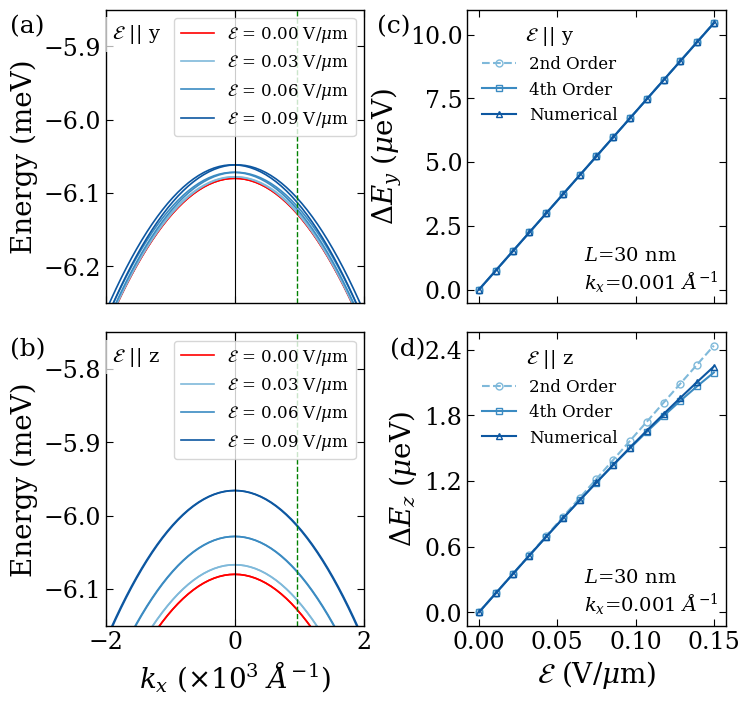

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ==============================================================
#                      GENERAL PARAMETERS
# ==============================================================
size = 50
nk = 51
kpoints = np.linspace(-0.002, 0.002, nk, endpoint=True) * 1000
efields_um = np.arange(0.03, 0.12, 0.03)

N = 100
L = 300
kx = 0.001
emax = 0.15

# ==================================================
# Global plot settings
# ==================================================
plt.rcParams.update({
    "figure.figsize": [8, 8],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",

    "axes.linewidth": 1.0,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# ==============================================================
#                      DATA LOADING
# ==============================================================

try:
    eval_array_E0 = np.loadtxt(
        f"band_data_y_E0.000_size{size}_nk{nk}.dat"
    )
except FileNotFoundError as e:
    print(f"Error loading band data: {e}")
    eval_array_E0 = np.zeros((nk, 2))

try:
    datay_pb = np.loadtxt(
        f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat",
        skiprows=1
    )

    datay_num = np.loadtxt(
        f"numerical_splitting_N{N}_L{L}_emax{emax:.2f}_y.dat",
        skiprows=1
    )

    Efield_split = datay_pb[:, 0]
    split_pb_2nd_y = datay_pb[:, 2]
    split_pb_4th_y = datay_pb[:, 3]
    split_num_y = datay_num[:, 3]

    dataz_pb = np.loadtxt(
        f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat",
        skiprows=1
    )

    dataz_num = np.loadtxt(
        f"numerical_splitting_N{N}_L{L}_emax{emax:.2f}_z.dat",
        skiprows=1
    )

    split_pb_2nd_z = dataz_pb[:, 2]
    split_pb_4th_z = dataz_pb[:, 3]
    split_num_z = dataz_num[:, 3]

except FileNotFoundError as e:
    print(f"Error loading splitting data: {e}")

    Efield_split = np.linspace(0, 0.1, 10)

    split_pb_2nd_y = np.zeros(10)
    split_pb_4th_y = np.zeros(10)
    split_num_y = np.zeros(10)

    split_pb_2nd_z = np.zeros(10)
    split_pb_4th_z = np.zeros(10)
    split_num_z = np.zeros(10)

# ==============================================================
#                      COLORS
# ==============================================================

cmap_bands = plt.cm.Blues
colors_bands = cmap_bands(np.linspace(0.45, 0.85, len(efields_um)))

cmap_blue_split = plt.cm.Blues
cmap_red_split = plt.cm.Reds

blue_colors_split = cmap_blue_split([0.45, 0.65, 0.85])
red_colors_split = cmap_red_split([0.45, 0.65, 0.85])

# ==============================================================
#                      HELPERS
# ==============================================================

def format_ax(ax):
    ax.tick_params(
        direction="in",
        bottom=True,
        top=True,
        left=True,
        right=True
    )
    # ax.minorticks_on()


def plot_bands_generic(ax, direction, ylim, text_y, title_label):
    """Plots band structure on a given axis."""

    # E = 0 reference
    ax.plot(
        kpoints,
        eval_array_E0[:, 0] * 1e3,
        color="red",
        lw=1.2,
        label=r"$\mathcal{E}$" f" = {(0.00):.2f}" r" V/$\mu$m"
    )

    ax.plot(
        kpoints,
        eval_array_E0[:, 1] * 1e3,
        color="red",
        lw=1.2
    )

    # Finite fields
    for idx, efield_um in enumerate(efields_um):

        datafile = f"band_data_{direction}_E{efield_um:.3f}_size{size}_nk{nk}.dat"

        try:
            eval_array_E = np.loadtxt(datafile)

            ax.plot(
                kpoints,
                eval_array_E[:, 0] * 1e3,
                color=colors_bands[idx],
                lw=1.2
            )

            lbl = r"$\mathcal{E}$" f" = {efield_um:.2f}" r" V/$\mu$m"

            ax.plot(
                kpoints,
                eval_array_E[:, 1] * 1e3,
                color=colors_bands[idx],
                lw=1.2,
                label=lbl
            )

        except FileNotFoundError:
            pass

    ax.axvline(0, color="black", linestyle="-", lw=0.8)
    ax.axhline(0, color="black", linestyle="-", lw=0.8)

    k_green = kpoints[int((nk - 1) / 2 + (nk - 1) / 4)]
    ax.axvline(k_green, color="green", linestyle="--", lw=1.0)

    ax.set_xlim(-2, 2)
    ax.set_ylim(*ylim)
    ax.set_xticks([-2, 0, 2])
    ax.set_ylabel("Energy (meV)")

    ax.legend(
        loc="upper right",
        frameon=True,
        fontsize=12
    )

    ax.text(
        -0.37,
        0.92,
        title_label,
        transform=ax.transAxes,
        fontsize=18
    )

    ax.text(
        -1.9,
        text_y,
        r"$\mathcal{E}$ || " + direction,
        fontsize=14,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )

    format_ax(ax)


# ==============================================================
#                      CREATE 2x2 GRID
# ==============================================================

fig, axs = plt.subplots(
    2, 2,
    sharex="col",
    sharey="none",
    figsize=(8, 8)
)

plt.subplots_adjust(wspace=0.40, hspace=0.10)

# ==============================================================
#                      ROW 0: E || Y
# ==============================================================

plot_bands_generic(
    axs[0, 0],
    "y",
    (-6.25, -5.85),
    -5.89,
    "(a)"
)

ax_split_y = axs[0, 1]

ax_split_y.plot(
    Efield_split,
    split_pb_2nd_y,
    marker="o",
    linestyle="--",
    color=blue_colors_split[0],
    label="2nd Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_y.plot(
    Efield_split,
    split_pb_4th_y,
    marker="s",
    linestyle="-",
    color=blue_colors_split[1],
    label="4th Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_y.plot(
    Efield_split,
    split_num_y,
    marker="^",
    linestyle="-",
    color=blue_colors_split[2],
    label="Numerical",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_y.set_ylabel(r"$\Delta E_y$ ($\mu$eV)")

ax_split_y.legend(
    frameon=False,
    fontsize=12,
    title=r"$\mathcal{E}$ || y",
    title_fontsize=14,
    loc="best"
)

ax_split_y.text(
    -0.35,
    0.92,
    "(c)",
    transform=ax_split_y.transAxes,
    fontsize=18
)

ax_split_y.text(
    0.45,
    0.05,
    f"$L$={int(L/10)} nm\n$k_x$={kx}" r" $\AA^{-1}$",
    transform=ax_split_y.transAxes,
    fontsize=14
)



format_ax(ax_split_y)

# ==============================================================
#                      ROW 1: E || Z
# ==============================================================

plot_bands_generic(
    axs[1, 0],
    "z",
    (-6.15, -5.75),
    -5.79,
    "(b)"
)

axs[1, 0].set_xlabel(
    r"$k_x$ ($\times$10$^3$ $\AA^{-1}$)"
)

ax_split_z = axs[1, 1]

ax_split_z.plot(
    Efield_split,
    split_pb_2nd_z,
    marker="o",
    linestyle="--",
    color=blue_colors_split[0],
    label="2nd Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_z.plot(
    Efield_split,
    split_pb_4th_z,
    marker="s",
    linestyle="-",
    color=blue_colors_split[1],
    label="4th Order",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_z.plot(
    Efield_split,
    split_num_z,
    marker="^",
    linestyle="-",
    color=blue_colors_split[2],
    label="Numerical",
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax_split_z.set_ylabel(r"$\Delta E_z$ ($\mu$eV)")
ax_split_z.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)")

ax_split_z.legend(
    frameon=False,
    fontsize=12,
    title=r"$\mathcal{E}$ || z",
    title_fontsize=14,
    loc="best"
)

ax_split_z.text(
    -0.30,
    0.92,
    "(d)",
    transform=ax_split_z.transAxes,
    fontsize=18
)

ax_split_z.text(
    0.45,
    0.05,
    f"$L$={int(L/10)} nm\n$k_x$={kx}" r" $\AA^{-1}$",
    transform=ax_split_z.transAxes,
    fontsize=14
)
format_ax(ax_split_z)

# ==============================================================
#                      TICKS
# ==============================================================

ax_split_y.yaxis.set_major_locator(
    MaxNLocator(nbins=5, prune="upper")
)

ax_split_z.yaxis.set_major_locator(
    MaxNLocator(nbins=5)
)

ax_split_z.xaxis.set_major_locator(
    MaxNLocator(nbins=4)
)

# ==============================================================
#                      SAVE AND SHOW
# ==============================================================

save_name = f"combined_band_splitting_grid_N{N}_L{L}_kx{kx}.png"
plt.savefig(save_name, dpi=300, bbox_inches="tight")

save_name = f"combined_band_splitting_grid_N{N}_L{L}_kx{kx}.pdf"
plt.savefig(save_name, dpi=300, bbox_inches="tight")

print(f"Plot saved as {save_name}")

plt.show()